# 1. Importing Libraries
Importing necessary libraries for computer vision (OpenCV), data manipulation (Pandas, NumPy), visualization (Matplotlib), and machine learning (Scikit-Learn).

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Loading the Dataset
Defining the file paths and loading the first 100 images for both the Basmati and Jasmine rice classes.

In [ ]:
dataset_path = "/content/drive/MyDrive/Rice_Image_Dataset"

# -> LOAD 100 + 100 IMAGES

basmati_list = os.listdir(dataset_path + "/Basmati")
jasmine_list = os.listdir(dataset_path + "/Jasmine")

basmati_files = []
jasmine_files = []

# Take first 100 images
for i in range(100):
    basmati_files.append(dataset_path + "/Basmati/" + basmati_list[i])
    jasmine_files.append(dataset_path + "/Jasmine/" + jasmine_list[i])

print("Basmati images:", len(basmati_files))
print("Jasmine images:", len(jasmine_files))

Basmati images: 100
Jasmine images: 100


# 3. Exploratory Data Analysis (EDA)
Visualizing random sample images from both classes alongside their grayscale pixel intensity histograms to see if there are clear differences in their distributions.

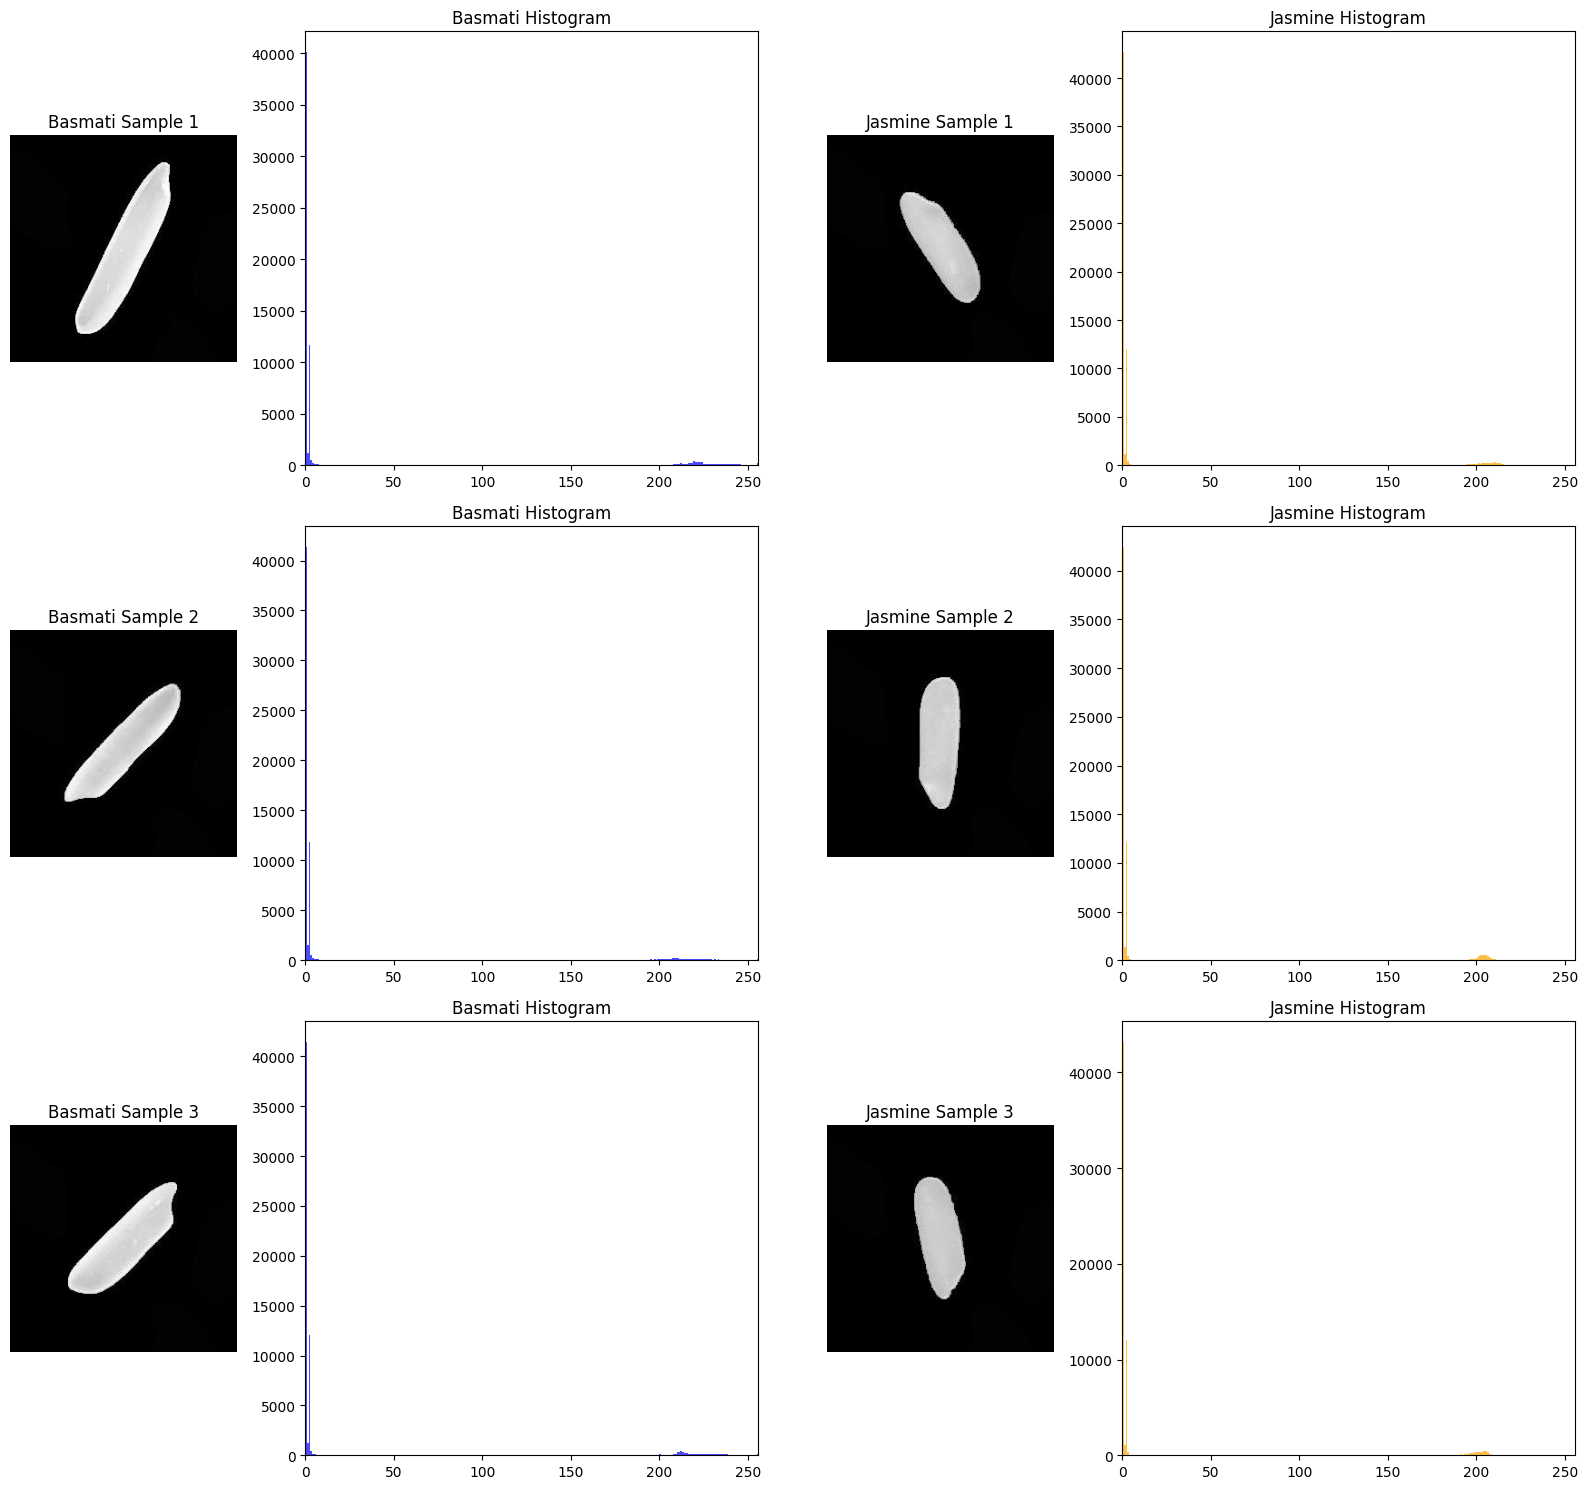

In [ ]:
# Select 3 random images from each class
sample_basmati = random.sample(basmati_files, 3)
sample_jasmine = random.sample(jasmine_files, 3)

# 4 columns are required (Basmati Img, Basmati Hist, Jasmine Img, Jasmine Hist)
# Using figsize=(16, 15) from the first version, but keeping the width_ratios for bigger histograms
fig, axes = plt.subplots(3, 4, figsize=(16, 15), gridspec_kw={'width_ratios': [1, 2, 1, 2]})

for i in range(3):
    # --- Basmati ---
    # Read image in grayscale
    b_img = cv2.imread(sample_basmati[i], cv2.IMREAD_GRAYSCALE)

    # Plot image
    axes[i, 0].imshow(b_img, cmap='gray')
    axes[i, 0].set_title(f"Basmati Sample {i+1}")
    axes[i, 0].axis('off')

    # Plot histogram
    axes[i, 1].hist(b_img.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.7)
    axes[i, 1].set_title("Basmati Histogram")
    axes[i, 1].set_xlim([0, 256])

    # --- Jasmine ---
    # Read image in grayscale
    j_img = cv2.imread(sample_jasmine[i], cv2.IMREAD_GRAYSCALE)

    # Plot image
    axes[i, 2].imshow(j_img, cmap='gray')
    axes[i, 2].set_title(f"Jasmine Sample {i+1}")
    axes[i, 2].axis('off')

    # Plot histogram
    axes[i, 3].hist(j_img.ravel(), bins=256, range=[0, 256], color='orange', alpha=0.7)
    axes[i, 3].set_title("Jasmine Histogram")
    axes[i, 3].set_xlim([0, 256])

plt.tight_layout()
plt.show()

# 4. Defining Preprocessing & Feature Extraction Functions
Creating reusable functions to process the images.
* **`preprocess_image`**: Applies a Gaussian blur and binary thresholding.
* **`extract_features`**: Finds contours and calculates geometric features (Area, Perimeter, Eccentricity, Compactness).

In [ ]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    blur = cv2.GaussianBlur(gray, (5,5), 0)

    _, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

    return thresh

In [ ]:
def extract_features(binary_img):

    contours, _ = cv2.findContours(binary_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)

    perimeter = cv2.arcLength(cnt, True)

    # Eccentricity
    if len(cnt) >= 5:
        ellipse = cv2.fitEllipse(cnt)
        (center, axes, angle) = ellipse

        major_axis = max(axes)
        minor_axis = min(axes)

        eccentricity = np.sqrt(1 - (minor_axis/major_axis)**2)
    else:
        eccentricity = 0

    # Compactness
    if area != 0:
        compactness = (perimeter**2) / (4 * np.pi * area)
    else:
        compactness = 0

    return [area, perimeter, eccentricity, compactness]

# 5. Visualizing the Preprocessing Pipeline
Demonstrating the step-by-step transformation (Grayscale -> Blur -> Threshold -> Contours) on a single sample image to verify the logic.

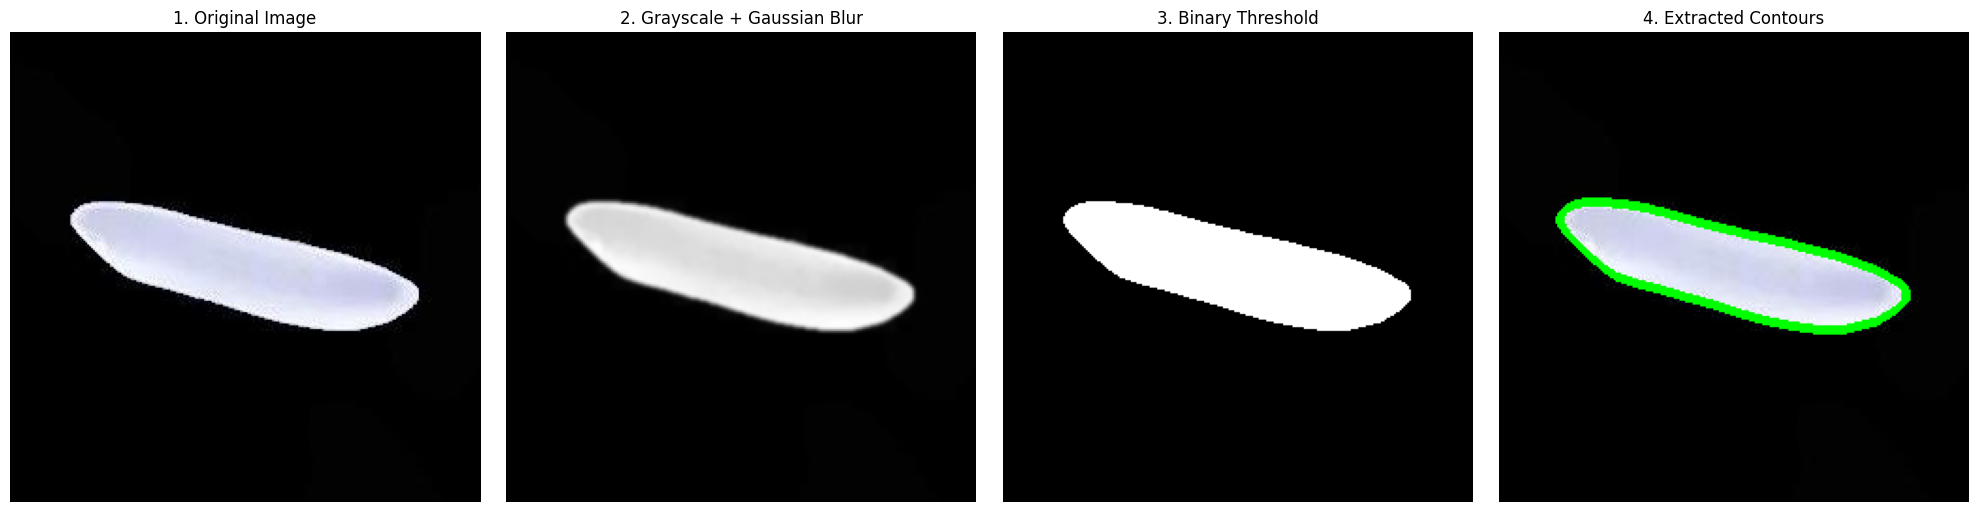

In [ ]:
# Grab one sample image to demonstrate the preprocessing pipeline
sample_img_path = basmati_files[0]

# 1. Read and convert for plotting
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Original
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Apply your preprocessing steps
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY)

# 3. Find contours to show feature extraction
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = img_rgb.copy()
cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 3)

# Plot the steps side-by-side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("1. Original Image")
axes[0].axis('off')

axes[1].imshow(blur, cmap='gray')
axes[1].set_title("2. Grayscale + Gaussian Blur")
axes[1].axis('off')

axes[2].imshow(thresh, cmap='gray')
axes[2].set_title("3. Binary Threshold")
axes[2].axis('off')

axes[3].imshow(contour_img)
axes[3].set_title("4. Extracted Contours")
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 6. Building the Feature Dataset
Looping through all images to extract their geometric features and storing them in a structured Pandas DataFrame along with their corresponding labels (0 for Basmati, 1 for Jasmine).

In [ ]:
data = []

# Basmati → label 0
for file in basmati_files:
    processed = preprocess_image(file)
    features = extract_features(processed)

    if features:
        data.append(features + [0])

# Jasmine → label 1
for file in jasmine_files:
    processed = preprocess_image(file)
    features = extract_features(processed)

    if features:
        data.append(features + [1])


columns = ["Area", "Perimeter", "Eccentricity", "Compactness", "Label"]
df = pd.DataFrame(data, columns=columns)

print("\nSample Data:")
print(df.sample(10))


Sample Data:
       Area   Perimeter  Eccentricity  Compactness  Label
71   7561.5  477.629505      0.981775     2.400847      0
8    7660.5  460.399056      0.975966     2.201922      0
152  5009.0  343.563489      0.958130     1.875224      1
91   7474.0  453.823375      0.966643     2.192859      0
126  5489.5  348.658942      0.939240     1.762215      1
95   6078.5  437.771639      0.980640     2.508932      0
15   6655.5  421.663995      0.975804     2.125898      0
92   6117.0  406.333041      0.973359     2.147909      0
106  4802.0  325.788885      0.954502     1.758897      1
148  4990.5  347.036578      0.956371     1.920422      1


# 7. Data Splitting
Separating the independent variables (Features) from the dependent variable (Label) and splitting the data into training (80%) and testing (20%) sets.

In [ ]:
X = df[["Area", "Perimeter", "Eccentricity", "Compactness"]]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 8. Model Training
Initializing and training a K-Nearest Neighbors (KNN) classifier using `k=3` on the training dataset.

In [ ]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

# 9. Model Evaluation
Evaluating the model's performance on the unseen test data using Accuracy, a Confusion Matrix, and a Classification Report.

In [ ]:
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.975

Confusion Matrix:
 [[21  0]
 [ 1 18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.95      0.97        19

    accuracy                           0.97        40
   macro avg       0.98      0.97      0.97        40
weighted avg       0.98      0.97      0.97        40



# 10. Building the Prediction Pipeline
Creating a function that takes a raw image path, runs it through the preprocessing and feature extraction steps, and outputs the model's prediction.

In [ ]:
def predict_image(image_path):

    processed = preprocess_image(image_path)
    features = extract_features(processed)

    if features:
        features_df = pd.DataFrame([features], columns=["Area", "Perimeter", "Eccentricity", "Compactness"])
        prediction = model.predict(features_df)
        return prediction[0]
    else:
        return None

In [ ]:
test_img = jasmine_files[0]

result = predict_image(test_img)

if result == 0:
    print("\nPredicted: Basmati")
else:
    print("\nPredicted: Jasmine")


Predicted: Jasmine


# 11. Interactive Prediction (Upload an Image)
An interactive cell that allows the user to upload their own image from their local machine and get a live prediction from the trained model.

Saving basmati (14117).jpg to basmati (14117) (1).jpg
Saving Jasmine (1744).jpg to Jasmine (1744) (1).jpg

Predicted: Basmati


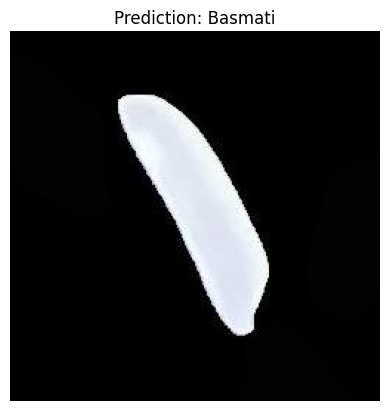


Predicted: Jasmine


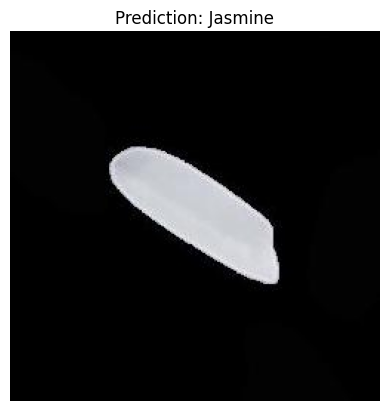

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# 1. Upload the file from your local machine
uploaded = files.upload()

for filename in uploaded.keys():
    # 2. Predict using your existing function
    result = predict_image(filename)

    # 3. Display the result
    if result == 0:
        prediction = "Basmati"
    elif result == 1:
        prediction = "Jasmine"
    else:
        prediction = "Unable to detect rice grain"

    print(f"\nPredicted: {prediction}")

    # 4. Show the image you uploaded
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {prediction}")
    plt.axis('off')
    plt.show()

# 12. Automated Random Prediction Test
Randomly selecting an image from the entire dataset to test the prediction pipeline programmatically.

In [ ]:
import random

# Combine both classes
all_images = basmati_files + jasmine_files

# Pick random image
test_img = random.choice(all_images)

result = predict_image(test_img)

if result == 0:
    print("\nPredicted: Basmati")
else:
    print("\nPredicted: Jasmine")


Predicted: Basmati
